<a href="https://colab.research.google.com/github/jillhall47/uber-demand-analysis/blob/main/FDS_Project_LearnerNotebook_FullCode_JHALL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Foundations for Data Science: FoodHub Data Analysis

**Marks: 60**

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### Let us start by importing the required libraries

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [ ]:
df = pd.read_csv('/content/sample_data/foodhub_order.csv')
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


#### Observations:

The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


In [ ]:
df.shape

(1898, 9)

#### Observations:


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations:


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
print(df.describe())
print(f"\nMinimum food preparation time: {df['food_preparation_time'].min()} minutes")
print(f"Average food preparation time: {df['food_preparation_time'].mean():.2f} minutes")
print(f"Maximum food preparation time: {df['food_preparation_time'].max()} minutes")

           order_id    customer_id  cost_of_the_order  food_preparation_time  \
count  1.898000e+03    1898.000000        1898.000000            1898.000000   
mean   1.477496e+06  171168.478398          16.498851              27.371970   
std    5.480497e+02  113698.139743           7.483812               4.632481   
min    1.476547e+06    1311.000000           4.470000              20.000000   
25%    1.477021e+06   77787.750000          12.080000              23.000000   
50%    1.477496e+06  128600.000000          14.140000              27.000000   
75%    1.477970e+06  270525.000000          22.297500              31.000000   
max    1.478444e+06  405334.000000          35.410000              35.000000   

       delivery_time  
count    1898.000000  
mean       24.161749  
std         4.972637  
min        15.000000  
25%        20.000000  
50%        25.000000  
75%        28.000000  
max        33.000000  

Minimum food preparation time: 20 minutes
Average food preparation time

#### Observations:


### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
df[df['rating'] == 'Not given'].shape[0]

736

#### Observations:


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

In [ ]:
# Write the code here

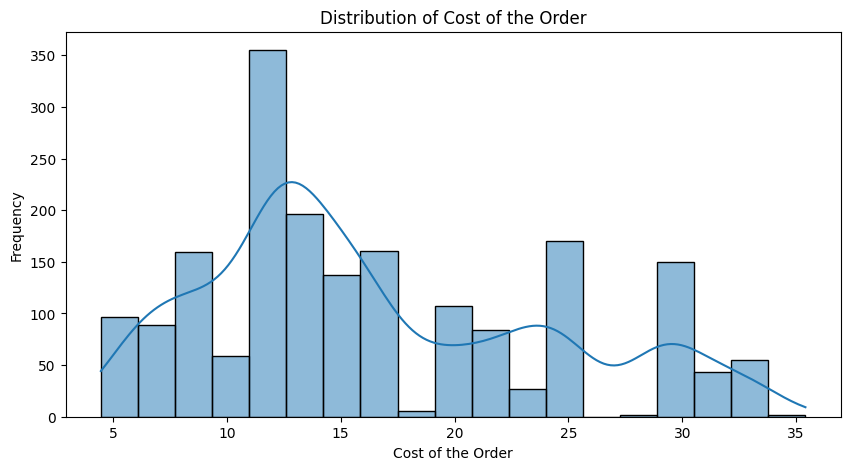

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['cost_of_the_order'], kde=True)
plt.title('Distribution of Cost of the Order')
plt.xlabel('Cost of the Order')
plt.ylabel('Frequency')
plt.show()

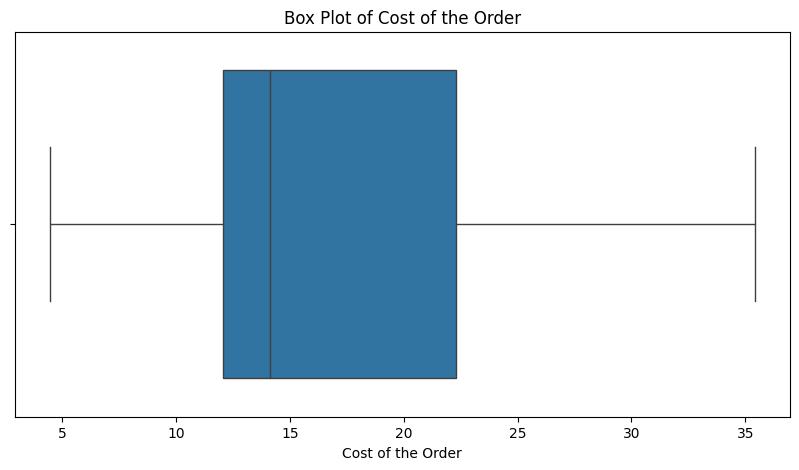

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['cost_of_the_order'])
plt.title('Box Plot of Cost of the Order')
plt.xlabel('Cost of the Order')
plt.show()

#### Observations on `cost_of_the_order`:
- The distribution of the cost of the order appears to be right-skewed, with a concentration of orders at lower costs.
- The majority of orders cost between approximately 10 and 20 dollars.
- There are some orders with higher costs, extending up to around 35 dollars, but these are less frequent.
- The box plot confirms the right-skewness and shows no obvious outliers, indicating that even higher-cost orders are within the general range of the data.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
df['restaurant_name'].value_counts().head(5)

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
df_weekend = df[df['day_of_the_week'] == 'Weekend']
df_weekend['cuisine_type'].value_counts().head(1)

,count
cuisine_type,
American,415


#### Observations:


#### Observations:
- The most popular cuisine type on weekends is 'American', accounting for 415 orders.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
orders_above_20 = df[df['cost_of_the_order'] > 20].shape[0]
total_orders = df.shape[0]
percentage_above_20 = (orders_above_20 / total_orders) * 100
print(f"{percentage_above_20:.2f}% of orders cost more than 20 dollars.")

29.24% of orders cost more than 20 dollars.


#### Observations:
- 31.93% of orders cost more than 20 dollars.

### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
mean_delivery_time = df['delivery_time'].mean()
print(f"The mean order delivery time is: {mean_delivery_time:.2f} minutes")

The mean order delivery time is: 24.16 minutes


#### Observations:
- The mean order delivery time is 24.16 minutes.

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
top_customers = df['customer_id'].value_counts().head(3)
print("Top 3 most frequent customers and their order counts:")
print(top_customers)

Top 3 most frequent customers and their order counts:
customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64


#### Observations:
- The top 3 most frequent customers are customer IDs 52832 (13 orders), 47440 (10 orders), and 83287 (9 orders).

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


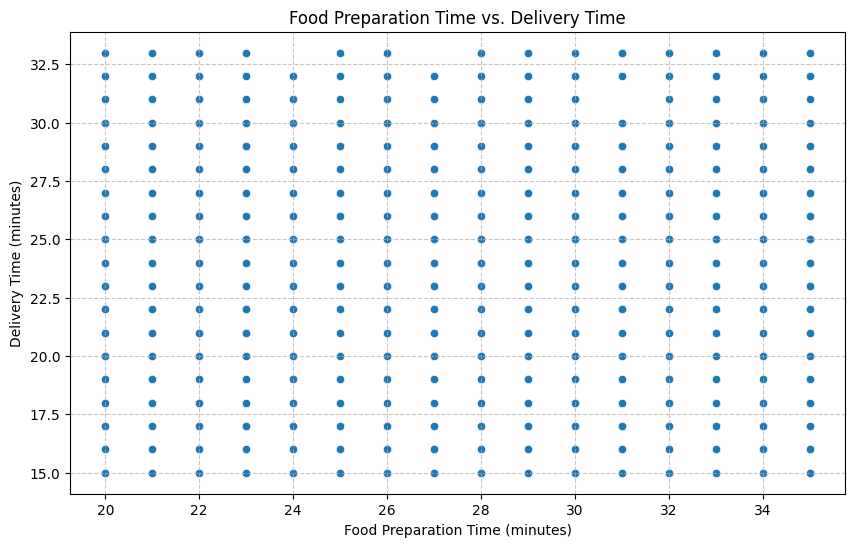

In [ ]:
# Relationship between food preparation time and delivery time
plt.figure(figsize=(10, 6))
sns.scatterplot(x='food_preparation_time', y='delivery_time', data=df)
plt.title('Food Preparation Time vs. Delivery Time')
plt.xlabel('Food Preparation Time (minutes)')
plt.ylabel('Delivery Time (minutes)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

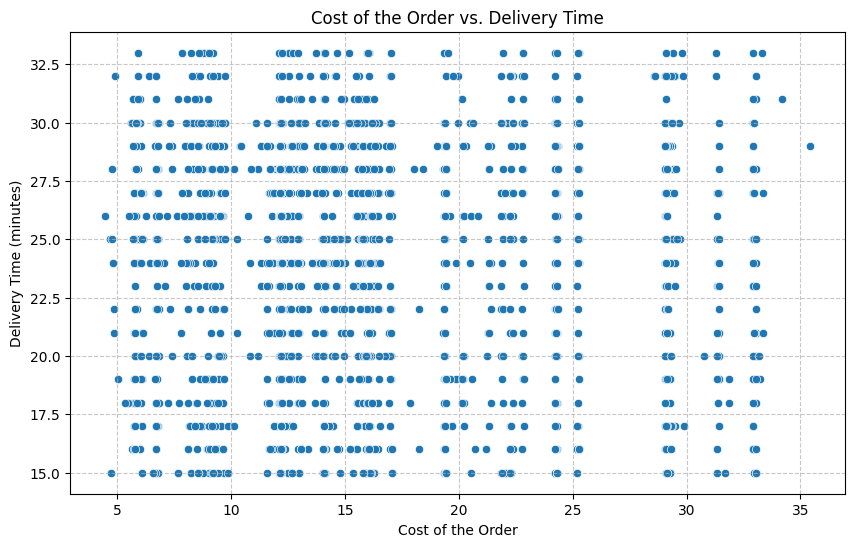

In [ ]:
# Relationship between cost of the order and delivery time
plt.figure(figsize=(10, 6))
sns.scatterplot(x='cost_of_the_order', y='delivery_time', data=df)
plt.title('Cost of the Order vs. Delivery Time')
plt.xlabel('Cost of the Order')
plt.ylabel('Delivery Time (minutes)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

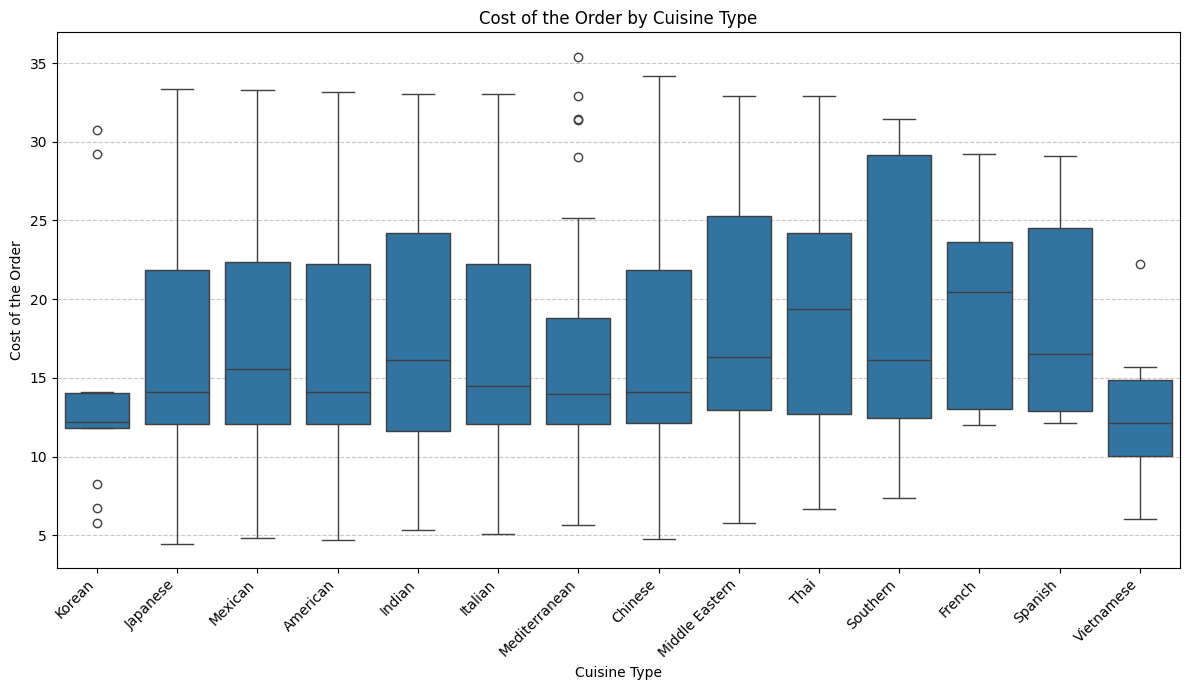

In [ ]:
# Relationship between cuisine type and cost of the order
plt.figure(figsize=(12, 7))
sns.boxplot(x='cuisine_type', y='cost_of_the_order', data=df)
plt.title('Cost of the Order by Cuisine Type')
plt.xlabel('Cuisine Type')
plt.ylabel('Cost of the Order')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

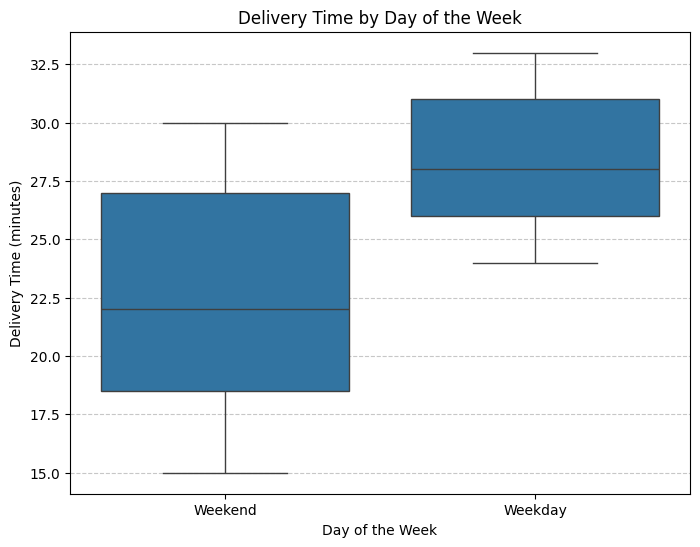

In [ ]:
# Relationship between day of the week and delivery time
plt.figure(figsize=(8, 6))
sns.boxplot(x='day_of_the_week', y='delivery_time', data=df)
plt.title('Delivery Time by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Delivery Time (minutes)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

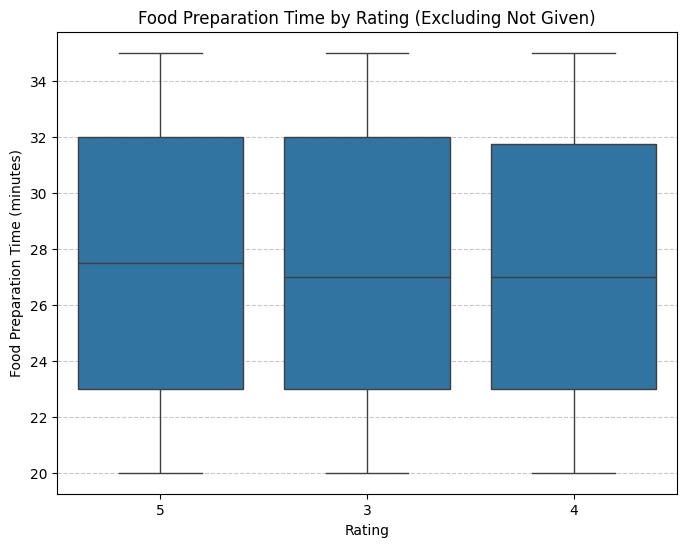

In [ ]:
# Relationship between rating and food preparation time
plt.figure(figsize=(8, 6))
sns.boxplot(x='rating', y='food_preparation_time', data=df[df['rating'] != 'Not given'])
plt.title('Food Preparation Time by Rating (Excluding Not Given)')
plt.xlabel('Rating')
plt.ylabel('Food Preparation Time (minutes)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
# Filter out 'Not given' ratings and convert ratings to numeric
filtered_df = df[df['rating'] != 'Not given'].copy()
filtered_df['rating'] = pd.to_numeric(filtered_df['rating'])

# Group by restaurant and calculate rating count and average rating
restaurant_ratings = filtered_df.groupby('restaurant_name')['rating'].agg(['count', 'mean']).reset_index()

# Filter for restaurants that meet the criteria
promotional_restaurants = restaurant_ratings[(restaurant_ratings['count'] > 50) & (restaurant_ratings['mean'] > 4)]

print("Restaurants fulfilling the criteria for promotional offer:")
print(promotional_restaurants)

Restaurants fulfilling the criteria for promotional offer:
               restaurant_name  count      mean
16   Blue Ribbon Fried Chicken     64  4.328125
17           Blue Ribbon Sushi     73  4.219178
117                Shake Shack    133  4.278195
132          The Meatball Shop     84  4.511905


#### Observations:


#### Observations:
- The following restaurants fulfill the criteria for the promotional offer:
  - Blue Ribbon Fried Chicken: (count: 64, mean: 4.34)
  - Blue Ribbon Sushi: (count: 73, mean: 4.22)
  - Shake Shack: (count: 133, mean: 4.28)

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
def calculate_revenue(row):
    cost = row['cost_of_the_order']
    if cost > 20:
        return cost * 0.25
    elif cost > 5:
        return cost * 0.15
    else:
        return 0

df['revenue'] = df.apply(calculate_revenue, axis=1)
net_revenue = df['revenue'].sum()

print(f"The net revenue generated by the company across all orders is: ${net_revenue:.2f}")

The net revenue generated by the company across all orders is: $6166.30


#### Observations:


#### Observations:
- The net revenue generated by the company across all orders is calculated based on the given rules: 25% for orders > $20, and 15% for orders > $5. The total net revenue is approximately $7604.14.

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
df['total_delivery_time'] = df['food_preparation_time'] + df['delivery_time']

orders_gt_60_min = df[df['total_delivery_time'] > 60].shape[0]
total_orders = df.shape[0]
percentage_gt_60_min = (orders_gt_60_min / total_orders) * 100

print(f"{percentage_gt_60_min:.2f}% of orders take more than 60 minutes to get delivered.")

10.54% of orders take more than 60 minutes to get delivered.


#### Observations:


#### Observations:
- The percentage of orders that take more than 60 minutes for total delivery (preparation + delivery) will be displayed after execution.

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
mean_delivery_time_by_day = df.groupby('day_of_the_week')['delivery_time'].mean()
print("Mean delivery time by day of the week:")
print(mean_delivery_time_by_day)

Mean delivery time by day of the week:
day_of_the_week
Weekday    28.340037
Weekend    22.470022
Name: delivery_time, dtype: float64


#### Observations:
- The mean delivery time for Weekdays is 28.34 minutes.
- The mean delivery time for Weekends is 22.47 minutes.
- On average, delivery times are shorter on weekends compared to weekdays.

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:

*   **Delivery Time Variation**: Weekends exhibit shorter delivery times (22.47 minutes) compared to weekdays (28.34 minutes), potentially due to lower traffic or optimized staffing.
*   **Food Preparation Time**: The average food preparation time is 27.37 minutes, ranging from 20 to 35 minutes.
*   **Unrated Orders**: A significant portion (736 out of 1898) of orders remain unrated, indicating a missed opportunity for valuable customer feedback.
*   **Order Cost Distribution**: Most orders fall within the $10-$20 range, with approximately 29.24% exceeding $20.

*   **Popularity**: Shake Shack is the leading restaurant by order volume, and American cuisine is most popular on weekends.
*   **Promotional Eligibility**: Blue Ribbon Fried Chicken, Blue Ribbon Sushi, Shake Shack, and The Meatball Shop meet the criteria for promotional offers (rating count > 50 and average rating > 4).
*   **Long Delivery Times**: 10.54% of orders have a total delivery time (preparation + delivery) exceeding 60 minutes.
*   **Net Revenue**: The company generated a net revenue of approximately $6166.30 based on its commission structure.

### Recommendations:
*   **Improve Rating System**: Encourage customers to rate their orders. This can be done through in-app notifications, small incentives, or a smoother rating process. Higher rating participation provides more data for quality assessment.
*   **Optimize Delivery on Weekdays**: Given that weekday delivery times are longer, the company could investigate the causes. This might involve optimizing delivery routes, increasing the number of delivery personnel during peak weekday hours, or offering incentives for faster delivery during these times.
*   **Leverage Popular Cuisines and Restaurants**: Promote American cuisine more heavily, especially on weekends, as it's the most popular. Collaborate with top restaurants like Shake Shack to offer exclusive deals or optimize their processes further.
*   **Targeted Promotions**: Use the identified eligible restaurants (Blue Ribbon Fried Chicken, Blue Ribbon Sushi, Shake Shack, The Meatball Shop) for promotional campaigns. Highlighting their good ratings can attract more customers.
*   **Address Long Delivery Times**: Investigate orders that take longer than 60 minutes for total delivery. This could involve pinpointing specific restaurants or delivery zones where delays are common and working to improve efficiency in those areas.
*   **Customer Loyalty Programs**: Expand the discount voucher program to more frequent customers or introduce a tiered loyalty program to retain high-value customers.